## Week6: Recurrent Neural Networks (RNNs) for seq-to-seq and seq-to-vec tasks

This notebook serves as part of the **Computer Intelligence and its Applications in Mechatronics** course at **Amirkabir University of Technology**. In this notebook, we will explore the implementation of Recurrent Neural Networks (RNNs) for sequence-to-sequence and sequence-to-vector tasks. We will itilize Keras and TensorFlow libraries to build and train our models. The focus will be on understanding the architecture of RNNs, their applications, and how to implement them effectively.

**Acknowledgment**  
Most parts of the code and ideas in this notebook are inspired by the excellent repository [ageron/handson-ml2](https://github.com/ageron/handson-ml2), created by **Aurélien Géron**, the author of the book *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*.

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import Callback, EarlyStopping
from IPython.display import clear_output

In [2]:
class LossPlotter(Callback):
    def on_train_begin(self, logs={}):
        self.i= 0
        self.x= []
        self.losses = []
        self.val_losses = []
        self.fig = plt.figure()
        self.logs = []

    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(logs)
        self.x.append(self.i)
        loss = logs.get('loss')
        self.losses.append(loss)
        self.val_losses.append(logs.get('val_loss'))
        self.i += 1

        clear_output(wait=True)
        plt.figure(figsize=(10, 6))
        plt.plot(self.x, self.losses, label="Loss")
        plt.plot(self.x, self.val_losses, label="Validation Loss")
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss Over Epochs')
        plt.legend()
        plt.grid('on')
        plt.show()

# Part1: Sequence to Vector Task
In this part, we will implement a simple RNN model for a sequence-to-vector task. We will use a synthetic dataset for demonstration purposes. The task will involve predicting a single output value based on a sequence of input values.


## Generating synthetic data

In [61]:
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    push = 1 * np.exp((time - offsets1))
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20))
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)
    series *= 1 + push * 2
    return series[..., np.newaxis].astype(np.float32)

In [62]:
n_samples = 10000
n_train = int(0.7*n_samples)
n_test = int(0.9*n_samples)
n_steps = 50
series = generate_time_series(n_samples, n_steps + 1)
X_train, y_train = series[:n_train, :n_steps], series[:n_train, -1]
X_valid, y_valid = series[n_train:n_test, :n_steps], series[n_train:n_test, -1]
X_test, y_test = series[n_test:, :n_steps], series[n_test:, -1]

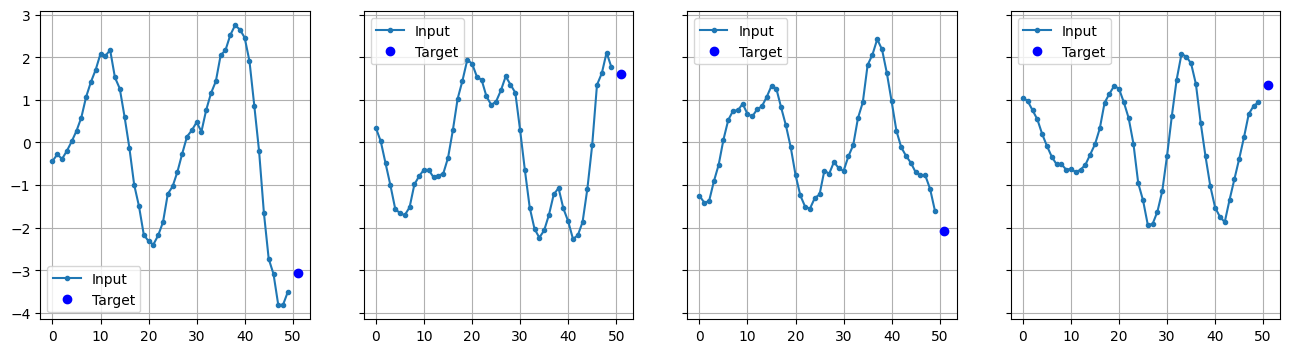

In [63]:
num_features = 4
fig, axes = plt.subplots(nrows=1, ncols=num_features, sharey=True, figsize=(num_features*4, 4))
for col in range(num_features):
    plt.sca(axes[col])
    plt.plot(X_valid[col, :, 0], ".-", label="Input")
    plt.plot(X_valid[col, :, 0].shape[0]+1,y_valid[col, 0], "bo", label="Target")
    plt.grid('on')
    plt.legend()

plt.show()

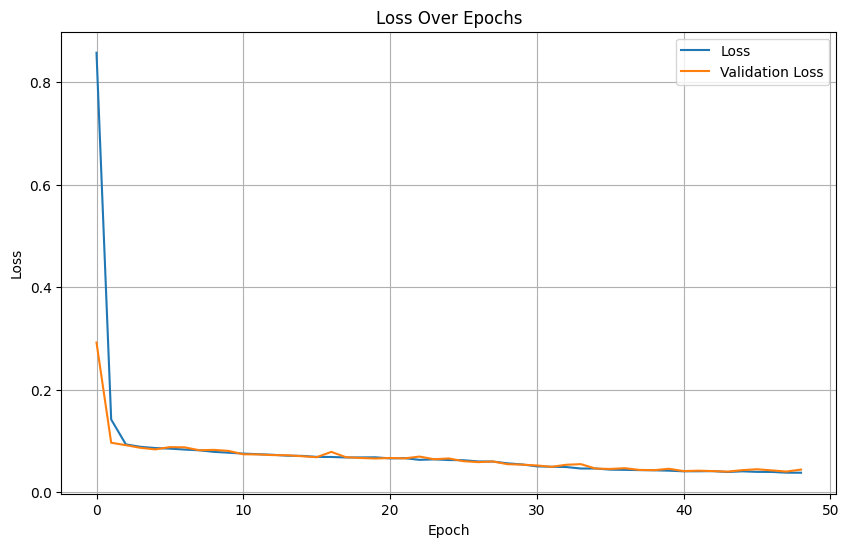

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0381 - val_loss: 0.0442
Epoch 49: early stopping
Restoring model weights from the end of the best epoch: 44.


In [64]:
model_sv = keras.models.Sequential([
    keras.layers.Input(shape=(None, 1)),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.GRU(20),
    keras.layers.Dense(1, activation='linear')
])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True , verbose=1)
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model_sv.compile(loss="mse", optimizer = optimizer)
history = model_sv.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid), callbacks=[LossPlotter(),early_stopping])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0403
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


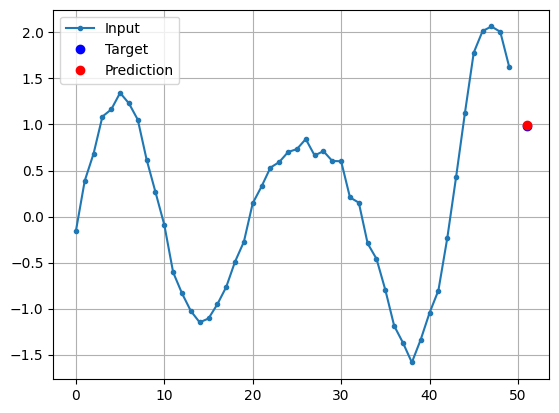

In [65]:
model_sv.evaluate(X_valid, y_valid)

random_sample = np.random.randint(0, n_test-n_train)
y_pred = model_sv.predict(X_valid)

plt.plot(X_valid[random_sample, :, 0], ".-", label="Input")
plt.plot(X_valid[random_sample, :, 0].shape[0]+1,y_valid[random_sample, 0], "bo", label="Target")
plt.plot(X_valid[random_sample, :, 0].shape[0]+1,y_pred[random_sample, 0], "ro", label="Prediction")
plt.grid('on')
plt.legend()
plt.show()



# Part2: Sequence to Sequence Task

In this part, we will implement a more complex RNN model for a sequence-to-sequence task. We will use the same synthetic dataset but modify the task to predict a sequence of output values based on a sequence of input values. This is commonly used in applications such as machine translation and text summarization.

In [67]:
step_ahead = 10
n_samples = 10000
n_train = int(0.7*n_samples)
n_test = int(0.9*n_samples)
n_steps = 50

series = generate_time_series(n_samples, n_steps + step_ahead)
X_train, y_train = series[:n_train, :n_steps], series[:n_train, -step_ahead:]
X_valid, y_valid = series[n_train:n_test, :n_steps], series[n_train:n_test, -step_ahead:]
X_test, y_test = series[n_test:, :n_steps], series[n_test:,-step_ahead:]

## Strategy Number 1: Predict one step at a time using trained sequence-to-vector model

The first option is to use the model we already trained, make it predict the next value, then add that value to the inputs and use the model again to predict the following value. This is a simple approach but can be inefficient and may not yield the best results.

In [68]:
X = X_test
Y = y_test

for step in range(step_ahead):
    y_pred_one = model_sv.predict(X, verbose=0)[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, -step_ahead:, 0]
Error = np.mean(keras.metrics.mse(Y, Y_pred))
print(f"Error: {Error}")

Error: 0.17515014111995697


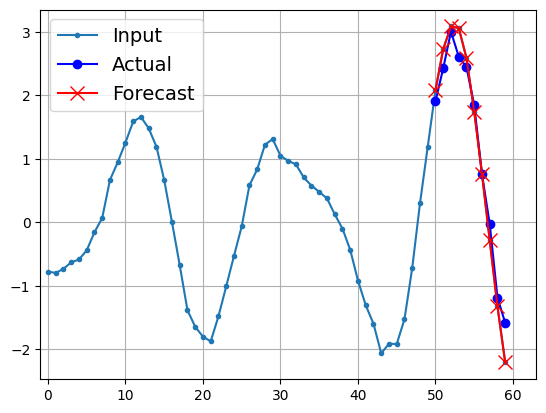

In [71]:
random_sample = np.random.randint(0, X.shape[0])

plt.plot(X[random_sample, :, 0], ".-", label="Input")
plt.plot(np.arange(n_steps, n_steps + step_ahead), Y[random_sample, :], "bo-", label="Actual")
plt.plot(np.arange(n_steps, n_steps + step_ahead), Y_pred[random_sample, :], "rx-", label="Forecast", markersize=10)
plt.xlim([-1, n_steps + step_ahead+3])
plt.grid('on')
plt.legend(fontsize=14)
plt.show()

## Strategy Number 2: Train a Sequence-to-Vector model that will learn 10 outputs simultaneously

The second option is to train a new model that will learn to predict 10 outputs simultaneously. We can still use a sequence-to-vector model, but it will output 10 values instead of 1.

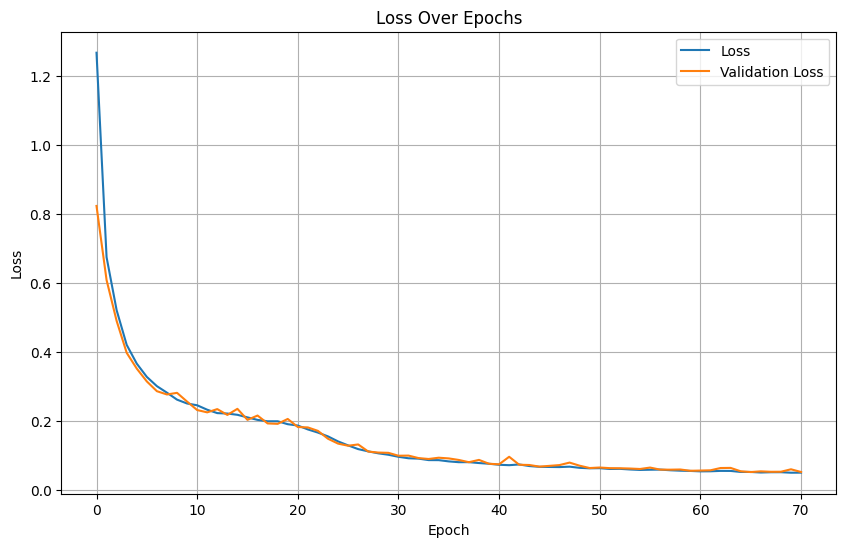

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0492 - val_loss: 0.0508
Epoch 71: early stopping
Restoring model weights from the end of the best epoch: 66.


In [72]:
model_sv_10O = keras.models.Sequential([
    keras.layers.Input(shape=(None, 1)),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.GRU(20),
    keras.layers.Dense(10, activation='linear')
])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True , verbose=1)
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model_sv_10O.compile(loss="mse", optimizer = optimizer)
history = model_sv_10O.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid), callbacks=[LossPlotter(),early_stopping])

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Error: 0.049440037459135056


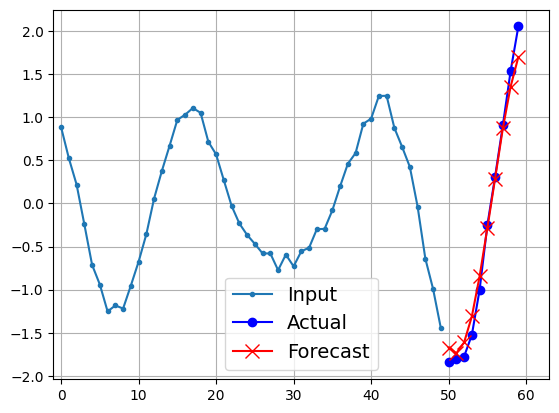

In [73]:
Y_pred = model_sv_10O.predict(X_test)[..., np.newaxis]
Error = np.mean(keras.metrics.mse(y_test, Y_pred))
print(f"Error: {Error}")

random_sample = np.random.randint(0, X_test.shape[0])

plt.plot(X_test[random_sample, :, 0], ".-", label="Input")
plt.plot(np.arange(n_steps, n_steps + step_ahead), y_test[random_sample, :], "bo-", label="Actual")
plt.plot(np.arange(n_steps, n_steps + step_ahead), Y_pred[random_sample, :], "rx-", label="Forecast", markersize=10)
plt.xlim([-1, n_steps + step_ahead+3])
plt.legend(fontsize=14)
plt.grid('on')

plt.show()

## Strategy Number 3: Training a sequence-to-sequence model
The third option is to train a sequence-to-sequence model. Instead of training the model to forecast the next 10 values only at the very last time step, we can train it to forecast the next 10 values at each and every time step. In other words, at time step 0 the model will output a vector containing the forecasts for time steps 1 to 10, then at time step 1 the model will forecast time steps 2 to 11, and so on.


In [75]:
step_ahead = 10
n_samples = 10000
n_train = int(0.7*n_samples)
n_test = int(0.9*n_samples)
n_steps = 50

series = generate_time_series(n_samples, n_steps + step_ahead)
X_train = series[:n_train, :n_steps]
X_valid = series[n_train:n_test, :n_steps]
X_test = series[n_test:, :n_steps]


Y = np.empty((10000, n_steps, step_ahead))
for step in range(1, step_ahead + 1):
    Y[..., step- 1] = series[..., step:step + n_steps, 0]
    
Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test = Y[9000:]

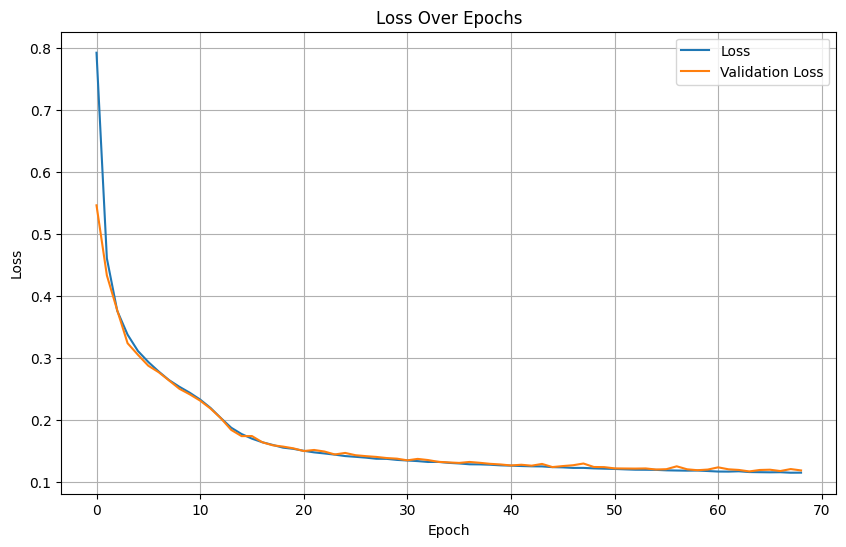

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - last_time_step_mse: 0.0541 - loss: 0.1155 - val_last_time_step_mse: 0.0582 - val_loss: 0.1183
Epoch 69: early stopping
Restoring model weights from the end of the best epoch: 64.


In [77]:
model_ss = keras.models.Sequential([
    keras.layers.Input(shape=(None, 1)),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

def last_time_step_mse(Y_true, Y_pred):
    return keras.metrics.mse(Y_true[:, -1], Y_pred[:, -1])

model_ss.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=0.001), metrics=[last_time_step_mse])
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True , verbose=1)
history = model_ss.fit(X_train, Y_train, epochs=200,
                    validation_data=(X_valid, Y_valid), callbacks=[LossPlotter(),early_stopping])


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Error: 0.1340789645910263


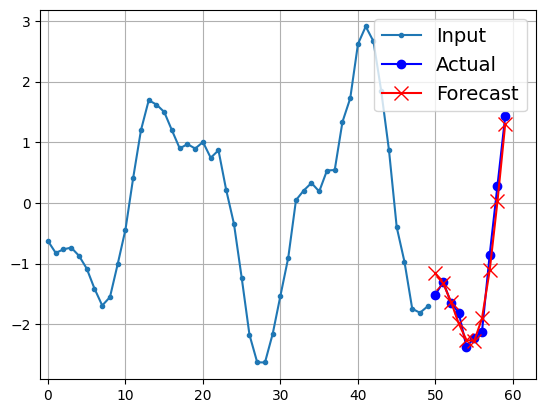

In [58]:
Y_pred = model_ss.predict(X_test)[..., np.newaxis]
Error = np.mean(keras.metrics.mse(Y_test, Y_pred))
print(f"Error: {Error}")

random_sample = np.random.randint(0, X_test.shape[0])

plt.plot(X_test[random_sample, :, 0], ".-", label="Input")
plt.plot(np.arange(n_steps, n_steps + step_ahead), Y_test[random_sample, :][-1,:], "bo-", label="Actual")
plt.plot(np.arange(n_steps, n_steps + step_ahead), Y_pred[random_sample, :][-1,:], "rx-", label="Forecast", markersize=10)
plt.xlim([-1, n_steps + step_ahead+3])
plt.legend(fontsize=14)
plt.grid('on')

plt.show()